# Evaluasi Akurasi Model Semantic Similarity
## RuangBaca Similarity API

Notebook ini memvisualisasikan hasil evaluasi dari `scripts/evaluate.py`.

**Alur penggunaan:**
1. Jalankan `python scripts/evaluate.py --token <SYNC_SECRET>` terlebih dahulu
2. Jalankan semua sel (`Run All`) — notebook otomatis memilih file JSON terbaru

**Output yang dihasilkan (disimpan ke `results/`):**
- `confusion_matrix.png` — gambar confusion matrix
- `threshold_sweep.png` — grafik Precision/Recall/F1 vs threshold
- `score_distribution.png` — distribusi skor per kelas
- `semantic_vs_lexical.png` — scatter plot skor semantik vs leksikal
- `summary_report.txt` — ringkasan teks siap salin ke laporan

---

In [7]:
import json
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# Premium Plot Styling
plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'DejaVu Sans', 'Arial']
sns.set_theme(style='ticks')

# Custom Palette
COLOR_MIRIP = '#10B981'    # Emerald
COLOR_TDK_MIRIP = '#EF4444' # Rose
COLOR_F1 = '#6366F1'       # Indigo
COLOR_PREC = '#0D9488'     # Teal
COLOR_REC = '#F59E0B'      # Amber
COLOR_ACC = '#8B5CF6'      # Purple

print('Setup complete. Libraries loaded.')

Setup complete. Libraries loaded.


## 1. Load Hasil Evaluasi

In [8]:
files = sorted(glob.glob('../results/eval_*.json'))
if not files:
    files = sorted(glob.glob('results/eval_*.json'))
if not files:
    raise FileNotFoundError(
        'Belum ada file hasil evaluasi.\n'
        'Jalankan: python scripts/evaluate.py --token SYNC_SECRET'
    )

EVAL_JSON = files[-1]
print(f'Memuat file data: {EVAL_JSON}')

with open(EVAL_JSON, encoding='utf-8') as f:
    data = json.load(f)

meta = data['meta']
target_metrics = data['target_threshold_metrics']
best_metrics = data['best_threshold_metrics']
metrics_df = pd.DataFrame(data['metrics_by_threshold'])
pred_df = pd.DataFrame(data['predictions'])

print('-' * 40)
print(f"Model    : {meta['model_name']}")
print(f"Backend  : {meta['model_backend']}")
print(f"Total data: {meta['total_pairs']} pasang judul")
print(f"Threshold target  : {meta['target_threshold']}")
print(f"Threshold terbaik : {meta['best_threshold']} (berdasarkan F1)")
print('-' * 40)

Memuat file data: ../results\eval_20260708_011012.json
----------------------------------------
Model    : paraphrase-multilingual-MiniLM-L12-v2
Backend  : sentence-transformers
Total data: 22 pasang judul
Threshold target  : 0.65
Threshold terbaik : 0.4 (berdasarkan F1)
----------------------------------------


## 2. Ringkasan Metrik pada Threshold Target

In [9]:
t = meta['target_threshold']
summary = pd.DataFrame([
    {'Metrik': 'Precision', 'Nilai': f"{target_metrics['precision']:.4f}", 'Persentase': f"{target_metrics['precision']*100:.1f}%"},
    {'Metrik': 'Recall',   'Nilai': f"{target_metrics['recall']:.4f}",    'Persentase': f"{target_metrics['recall']*100:.1f}%"},
    {'Metrik': 'F1-Score', 'Nilai': f"{target_metrics['f1']:.4f}",        'Persentase': f"{target_metrics['f1']*100:.1f}%"},
    {'Metrik': 'Accuracy', 'Nilai': f"{target_metrics['accuracy']:.4f}",  'Persentase': f"{target_metrics['accuracy']*100:.1f}%"},
    {'Metrik': 'True Positives (TP)',  'Nilai': str(target_metrics['tp']), 'Persentase': ''},
    {'Metrik': 'False Positives (FP)', 'Nilai': str(target_metrics['fp']), 'Persentase': ''},
    {'Metrik': 'False Negatives (FN)', 'Nilai': str(target_metrics['fn']), 'Persentase': ''},
    {'Metrik': 'True Negatives (TN)',  'Nilai': str(target_metrics['tn']), 'Persentase': ''},
])
summary.style.hide(axis='index').set_caption(f'Metrik Akurasi pada Threshold = {t}')

Metrik,Nilai,Persentase
Precision,1.0000,100.0%
Recall,0.5455,54.5%
F1-Score,0.7059,70.6%
Accuracy,0.7727,77.3%
True Positives (TP),6,
False Positives (FP),0,
False Negatives (FN),5,
True Negatives (TN),11,


## 3. Confusion Matrix

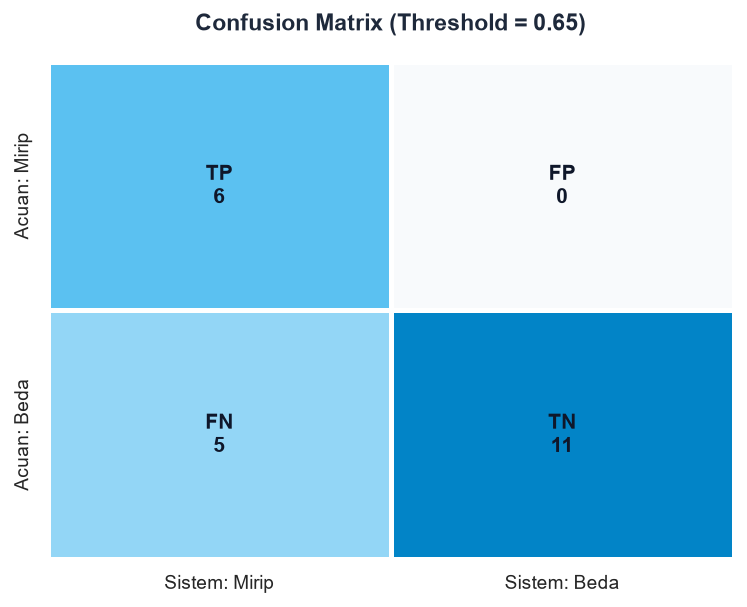

Gambar disimpan ke: ../results\confusion_matrix.png


In [10]:
tp, fp = target_metrics['tp'], target_metrics['fp']
fn, tn = target_metrics['fn'], target_metrics['tn']

cm = np.array([[tp, fp], [fn, tn]])
annot_labels = [
    [f'TP\n{tp}', f'FP\n{fp}'],
    [f'FN\n{fn}', f'TN\n{tn}']
]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
# Custom clean color map (Sky Blue -> Deep Ocean Blue)
cmap = LinearSegmentedColormap.from_list('cool_clean', ['#F8FAFC', '#E0F2FE', '#0ea5e9', '#0284c7'])

sns.heatmap(
    cm, annot=annot_labels, fmt='', cmap=cmap,
    xticklabels=['Sistem: Mirip', 'Sistem: Beda'],
    yticklabels=['Acuan: Mirip', 'Acuan: Beda'],
    linewidths=2.5, linecolor='white', ax=ax, cbar=False,
    annot_kws={'size': 11, 'weight': 'bold', 'color': '#0F172A'},
)

ax.set_title(
    f"Confusion Matrix (Threshold = {meta['target_threshold']})",
    fontsize=12, fontweight='bold', pad=16, color='#1E293B'
)
ax.tick_params(axis='both', which='both', length=0, labelsize=10, pad=8)
plt.tight_layout()

out_dir = '../results' if os.path.exists('../results') else 'results'
out_path = os.path.join(out_dir, 'confusion_matrix.png')
plt.savefig(out_path, bbox_inches='tight', dpi=200)
plt.show()
print(f'Gambar disimpan ke: {out_path}')


## 4. Precision / Recall / F1 vs Threshold

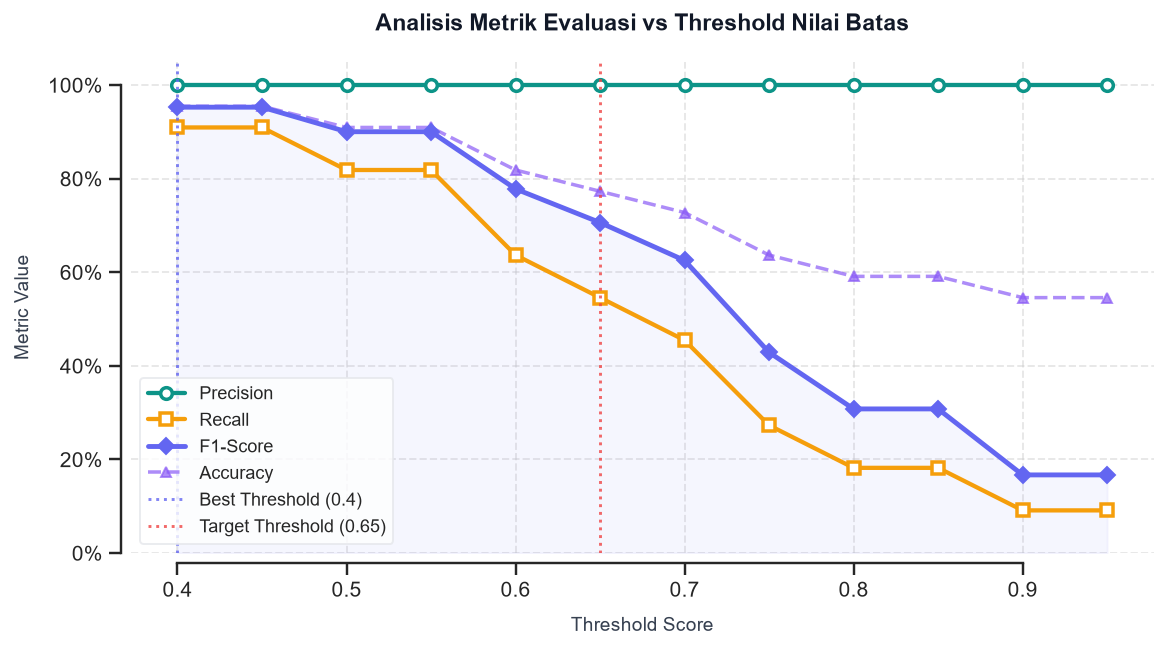

Gambar disimpan ke: ../results\threshold_sweep.png


In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

# Plot curves with customized lines, weights and markers
ax.plot(metrics_df['threshold'], metrics_df['precision'], 'o-',  label='Precision',  color=COLOR_PREC, lw=2.2, ms=6, markerfacecolor='white', markeredgewidth=1.8)
ax.plot(metrics_df['threshold'], metrics_df['recall'],    's-',  label='Recall',     color=COLOR_REC,  lw=2.2, ms=6, markerfacecolor='white', markeredgewidth=1.8)
ax.plot(metrics_df['threshold'], metrics_df['f1'],        'D-',  label='F1-Score',   color=COLOR_F1,   lw=2.5, ms=6, zorder=5)
ax.plot(metrics_df['threshold'], metrics_df['accuracy'],  '^--', label='Accuracy',   color=COLOR_ACC,  lw=1.8, ms=5, alpha=0.7)

# Highlight F1 Area slightly to emphasize balanced metric
ax.fill_between(metrics_df['threshold'], metrics_df['f1'], color=COLOR_F1, alpha=0.06)

# Vertical guide lines for thresholds
best_t   = meta['best_threshold']
target_t = meta['target_threshold']
ax.axvline(best_t,   color=COLOR_F1,    linestyle=':', lw=1.5, alpha=0.8, label=f'Best Threshold ({best_t})')
ax.axvline(target_t, color='#EF4444',   linestyle=':', lw=1.5, alpha=0.8, label=f'Target Threshold ({target_t})')

# Styling details
ax.set_xlabel('Threshold Score', fontsize=10, labelpad=8, color='#374151')
ax.set_ylabel('Metric Value', fontsize=10, labelpad=8, color='#374151')
ax.set_title('Analisis Metrik Evaluasi vs Threshold Nilai Batas', fontsize=12, fontweight='bold', pad=16, color='#111827')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='#E5E7EB', fontsize=9.5)
ax.grid(True, linestyle='--', alpha=0.45)
sns.despine(trim=True, offset=5)

plt.tight_layout()
out_path = os.path.join(out_dir, 'threshold_sweep.png')
plt.savefig(out_path, bbox_inches='tight', dpi=200)
plt.show()
print(f'Gambar disimpan ke: {out_path}')

## 5. Distribusi Skor Similarity

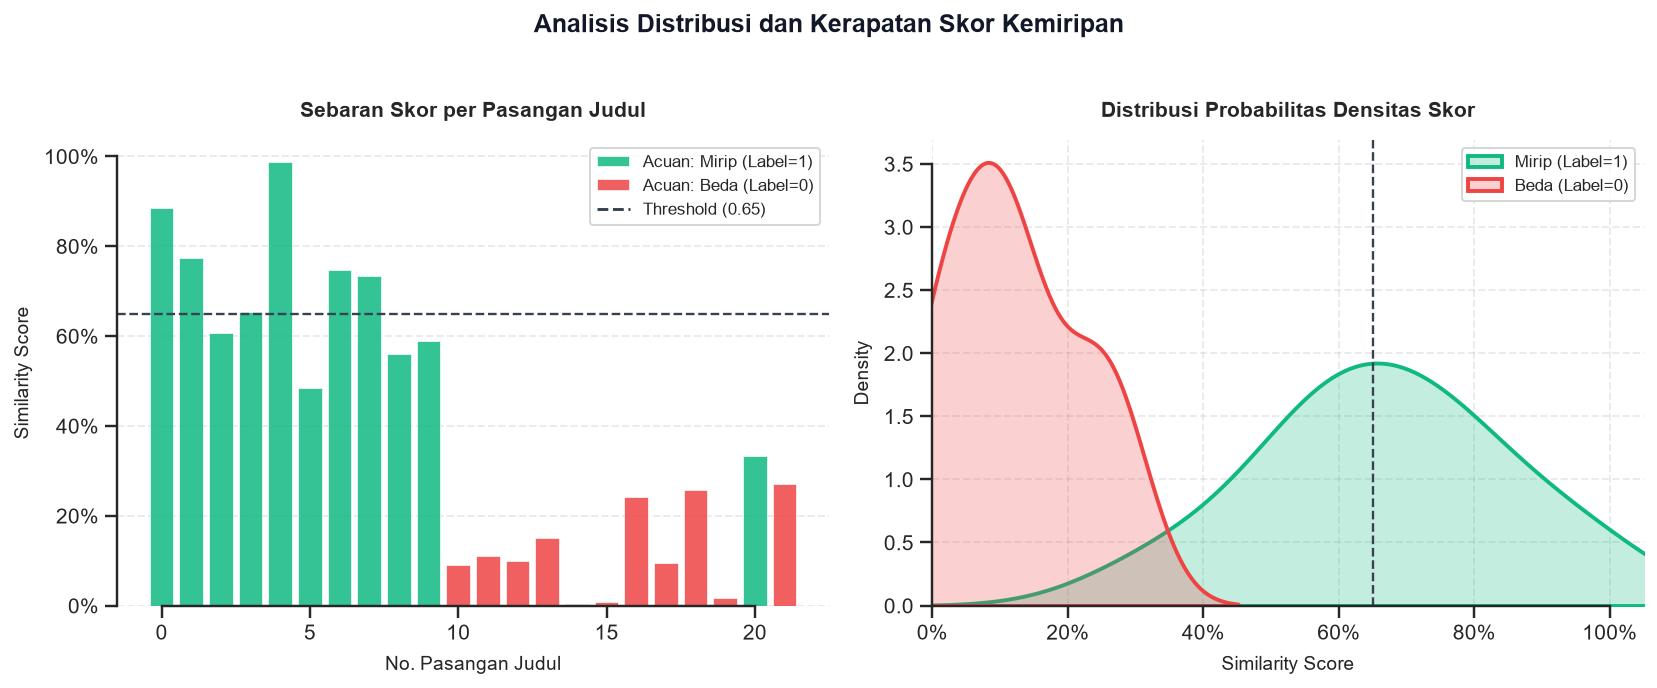

Gambar disimpan ke: ../results\score_distribution.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
t = meta['target_threshold']

# ── Bar Plot (Kiri) ──
bar_colors = [COLOR_MIRIP if l == 1 else COLOR_TDK_MIRIP for l in pred_df['label']]
bars = axes[0].bar(range(len(pred_df)), pred_df['score'], color=bar_colors, edgecolor='white', lw=0.4, alpha=0.85)
axes[0].axhline(t, color='#374151', linestyle='--', lw=1.2, label=f'Threshold Target ({t})')

axes[0].set_xlabel('No. Pasangan Judul', fontsize=10, labelpad=6)
axes[0].set_ylabel('Similarity Score', fontsize=10, labelpad=6)
axes[0].set_title('Sebaran Skor per Pasangan Judul', fontsize=11, fontweight='bold', pad=12)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

legend_elements = [
    Patch(facecolor=COLOR_MIRIP, label='Acuan: Mirip (Label=1)', alpha=0.85),
    Patch(facecolor=COLOR_TDK_MIRIP, label='Acuan: Beda (Label=0)', alpha=0.85),
    plt.Line2D([0], [0], color='#374151', linestyle='--', label=f'Threshold ({t})')
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=8.5)
sns.despine(ax=axes[0], trim=True)

# ── Density KDE Plot (Kanan) ──
mirip_scores = pred_df[pred_df['label'] == 1]['score']
beda_scores  = pred_df[pred_df['label'] == 0]['score']

sns.kdeplot(mirip_scores, ax=axes[1], fill=True, color=COLOR_MIRIP, label='Mirip (Label=1)', alpha=0.25, lw=2)
sns.kdeplot(beda_scores,  ax=axes[1], fill=True, color=COLOR_TDK_MIRIP, label='Beda (Label=0)', alpha=0.25, lw=2)
axes[1].axvline(t, color='#374151', linestyle='--', lw=1.2)

axes[1].set_xlabel('Similarity Score', fontsize=10, labelpad=6)
axes[1].set_ylabel('Density', fontsize=10, labelpad=6)
axes[1].set_title('Distribusi Probabilitas Densitas Skor', fontsize=11, fontweight='bold', pad=12)
axes[1].set_xlim(0, 1.05)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[1].legend(fontsize=8.5)
axes[1].grid(True, linestyle='--', alpha=0.4)
sns.despine(ax=axes[1], trim=True)

plt.suptitle('Analisis Distribusi dan Kerapatan Skor Kemiripan', fontsize=13, fontweight='bold', y=1.02, color='#111827')
plt.tight_layout()
out_path = os.path.join(out_dir, 'score_distribution.png')
plt.savefig(out_path, bbox_inches='tight', dpi=200)
plt.show()
print(f'Gambar disimpan ke: {out_path}')

## 6. Semantic vs Lexical Score

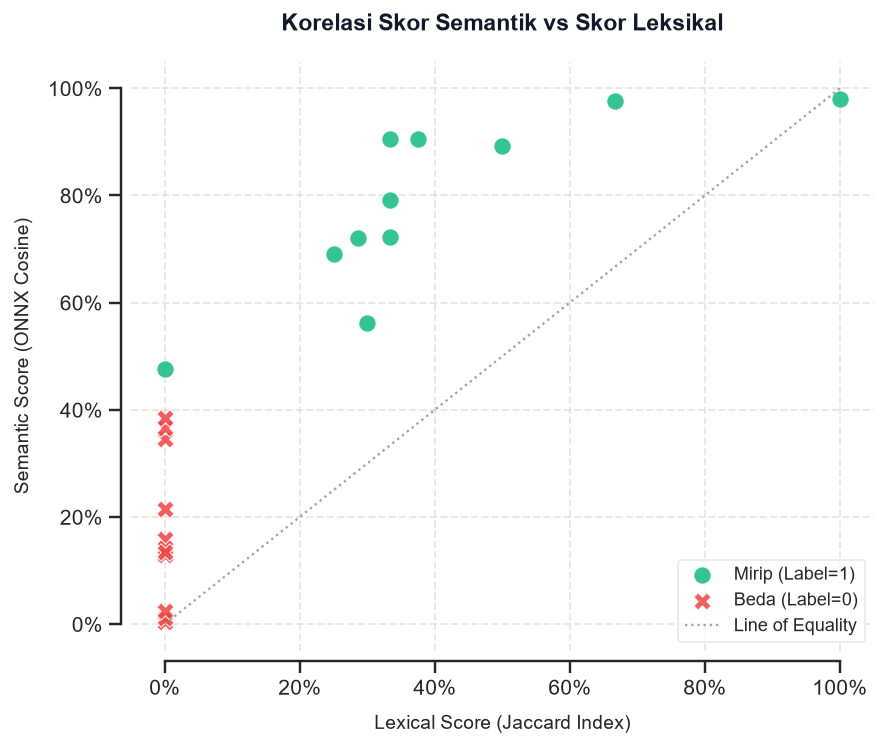

Gambar disimpan ke: ../results\semantic_vs_lexical.png


In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

# Plot positive and negative pairs
ax.scatter(
    pred_df[pred_df['label'] == 1]['lexical_score'],
    pred_df[pred_df['label'] == 1]['semantic_score'],
    color=COLOR_MIRIP, marker='o', s=80, alpha=0.85, label='Mirip (Label=1)', edgecolors='white', linewidths=0.6
)
ax.scatter(
    pred_df[pred_df['label'] == 0]['lexical_score'],
    pred_df[pred_df['label'] == 0]['semantic_score'],
    color=COLOR_TDK_MIRIP, marker='X', s=80, alpha=0.85, label='Beda (Label=0)', edgecolors='white', linewidths=0.6
)

# Diagonal line
ax.plot([0, 1], [0, 1], linestyle=':', color='#9CA3AF', lw=1.2, label='Line of Equality')

ax.set_xlabel('Lexical Score (Jaccard Index)', fontsize=10, labelpad=8)
ax.set_ylabel('Semantic Score (ONNX Cosine)', fontsize=10, labelpad=8)
ax.set_title('Korelasi Skor Semantik vs Skor Leksikal', fontsize=12, fontweight='bold', pad=16, color='#111827')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#E5E7EB', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.45)
sns.despine(trim=True, offset=5)

plt.tight_layout()
out_path = os.path.join(out_dir, 'semantic_vs_lexical.png')
plt.savefig(out_path, bbox_inches='tight', dpi=200)
plt.show()
print(f'Gambar disimpan ke: {out_path}')

## 7. Tabel Detail Prediksi

In [14]:
t = meta['target_threshold']
pred_df['pred']    = (pred_df['score'] >= t).astype(int)
pred_df['correct'] = pred_df['pred'] == pred_df['label']

def highlight_wrong(row):
    color = '' if row['correct'] else 'background-color: #FEF2F2; color: #991B1B' # Soft red text/bg for error
    return [color] * len(row)

disp = pred_df[['no','judul_a','judul_b','label','pred','score',
                 'semantic_score','lexical_score','level','correct']].copy()
for col in ['score','semantic_score','lexical_score']:
    disp[col] = disp[col].map('{:.3f}'.format)

disp.style.apply(highlight_wrong, axis=1).hide(axis='index').set_caption(
    f'Detail Evaluasi Prediksi per Pasangan Judul (Batas Merah = Prediksi Keliru pada Threshold={t})'
)

no,judul_a,judul_b,label,pred,score,semantic_score,lexical_score,level,correct
1,Implementasi Algoritma K-Nearest Neighbor untuk Klasifikasi Penyakit Diabetes,Penerapan Metode K-Nearest Neighbor dalam Klasifikasi Diabetes Mellitus,1,1,0.884,0.977,0.667,SANGAT TINGGI,True
2,Sistem Informasi Manajemen Perpustakaan Berbasis Web,Rancang Bangun Sistem Informasi Perpustakaan Berbasis Web,1,1,0.775,0.892,0.500,TINGGI,True
3,Deteksi Penyakit Tanaman Padi Menggunakan Convolutional Neural Network,Klasifikasi Penyakit Pada Tanaman Padi Berbasis CNN,1,0,0.606,0.723,0.333,SEDANG,False
4,Aplikasi Monitoring Kehadiran Mahasiswa Berbasis Android,Sistem Absensi Mahasiswa Menggunakan Aplikasi Mobile Android,1,1,0.654,0.791,0.333,SEDANG,True
5,Sistem Rekomendasi Film Menggunakan Collaborative Filtering,Implementasi Collaborative Filtering untuk Rekomendasi Film,1,1,0.986,0.981,1.000,SANGAT TINGGI,True
6,Analisis Sentimen Ulasan Produk E-commerce Menggunakan Naive Bayes,Klasifikasi Sentimen Review Toko Online dengan Metode Naive Bayes,1,0,0.484,0.562,0.300,RENDAH,False
7,Prediksi Harga Rumah Menggunakan Algoritma Random Forest,Peramalan Harga Properti Berbasis Random Forest Regression,1,1,0.747,0.906,0.375,TINGGI,True
8,Sistem Deteksi Wajah Menggunakan Metode Viola-Jones,Implementasi Face Detection dengan Algoritma Viola-Jones,1,1,0.734,0.906,0.333,TINGGI,True
9,Rancang Bangun Aplikasi Point of Sale Berbasis Web untuk UMKM,Pengembangan Sistem Kasir Point of Sale Berbasis Website untuk Usaha Kecil Menengah,1,0,0.559,0.692,0.250,SEDANG,False
10,Optimasi Rute Pengiriman Menggunakan Algoritma Dijkstra,Penerapan Algoritma Dijkstra untuk Pencarian Rute Terpendek pada Sistem Logistik,1,0,0.590,0.720,0.286,SEDANG,False


## 8. Tabel Threshold Sweep

In [15]:
best_t = meta['best_threshold']

def highlight_best(row):
    color = 'background-color: #ECFDF5; color: #065F46; font-weight: bold' if row['threshold'] == best_t else ''
    return [color] * len(row)

sweep = metrics_df.copy()
for col in ['precision','recall','f1','accuracy']:
    sweep[col] = sweep[col].map('{:.4f}'.format)

sweep.style.apply(highlight_best, axis=1).hide(axis='index').set_caption(
    f'Matrik Evaluasi Komprehensif pada Berbagai Batas Threshold (Sorotan Hijau = Akurasi F1 Terbaik)'
)

threshold,tp,fp,fn,tn,precision,recall,f1,accuracy
0.400000,10,0,1,11,1.0000,0.9091,0.9524,0.9545
0.450000,10,0,1,11,1.0000,0.9091,0.9524,0.9545
0.500000,9,0,2,11,1.0000,0.8182,0.9000,0.9091
0.550000,9,0,2,11,1.0000,0.8182,0.9000,0.9091
0.600000,7,0,4,11,1.0000,0.6364,0.7778,0.8182
0.650000,6,0,5,11,1.0000,0.5455,0.7059,0.7727
0.700000,5,0,6,11,1.0000,0.4545,0.6250,0.7273
0.750000,3,0,8,11,1.0000,0.2727,0.4286,0.6364
0.800000,2,0,9,11,1.0000,0.1818,0.3077,0.5909
0.850000,2,0,9,11,1.0000,0.1818,0.3077,0.5909


## 9. Export Ringkasan ke Teks

In [16]:
report_lines = [
    '=' * 52,
    '  RINGKASAN EVALUASI MODEL SIMILARITY',
    '=' * 52,
    f"  Model     : {meta['model_name']}",
    f"  Backend   : {meta['model_backend']}",
    f"  Timestamp : {meta['timestamp']}",
    f"  Pasangan  : {meta['total_pairs']}",
    '-' * 52,
    f"  THRESHOLD TARGET : {meta['target_threshold']}",
    f"  Precision        : {target_metrics['precision']:.4f}",
    f"  Recall           : {target_metrics['recall']:.4f}",
    f"  F1-Score         : {target_metrics['f1']:.4f}",
    f"  Accuracy         : {target_metrics['accuracy']:.4f}",
    f"  TP={target_metrics['tp']}  FP={target_metrics['fp']}  FN={target_metrics['fn']}  TN={target_metrics['tn']}",
    '-' * 52,
    f"  THRESHOLD TERBAIK (F1) : {best_metrics['threshold']}",
    f"  Precision              : {best_metrics['precision']:.4f}",
    f"  Recall                 : {best_metrics['recall']:.4f}",
    f"  F1-Score               : {best_metrics['f1']:.4f}",
    f"  Accuracy               : {best_metrics['accuracy']:.4f}",
    '=' * 52,
]
report = '\n'.join(report_lines)
print(report)

out = '../results/summary_report.txt' if os.path.exists('../results') else 'results/summary_report.txt'
with open(out, 'w', encoding='utf-8') as f:
    f.write(report)
print(f'\nSaved: {out}')

  RINGKASAN EVALUASI MODEL SIMILARITY
  Model     : paraphrase-multilingual-MiniLM-L12-v2
  Backend   : sentence-transformers
  Timestamp : 2026-07-08T01:10:12.971158
  Pasangan  : 22
----------------------------------------------------
  THRESHOLD TARGET : 0.65
  Precision        : 1.0000
  Recall           : 0.5455
  F1-Score         : 0.7059
  Accuracy         : 0.7727
  TP=6  FP=0  FN=5  TN=11
----------------------------------------------------
  THRESHOLD TERBAIK (F1) : 0.4
  Precision              : 1.0000
  Recall                 : 0.9091
  F1-Score               : 0.9524
  Accuracy               : 0.9545

Saved: ../results/summary_report.txt
